# Eye-Heart Connection: Hackathon Showcase
This notebook is a visual walkthrough of our **multimodal retinal cardiovascular risk project**.
It covers:
- data and split overview
- multimodal model approach (left eye + right eye + age)
- training behavior
- validation/test/evaluation outcomes
- single-sample inference demo using trained checkpoint
- deployment readiness checklist


## 1) Setup and Artifact Discovery
This cell resolves paths from your local project folder and checks required files.


In [1]:
from __future__ import annotations
import json
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from sklearn.metrics import roc_curve, precision_recall_curve, auc
from IPython.display import display
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)
LABELS = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
LABEL_NAMES = {
    'N': 'Normal',
    'D': 'Diabetes',
    'G': 'Glaucoma',
    'C': 'Cataract',
    'A': 'AMD',
    'H': 'Hypertension',
    'M': 'Myopia',
    'O': 'Other',
}
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'configs').exists():
    raise FileNotFoundError(f'Project root not found from notebook location: { PROJECT_ROOT }')
DATA_DIR = PROJECT_ROOT / 'data'
PROCESSED_DIR = DATA_DIR / 'processed'
SPLITS_DIR = DATA_DIR / 'splits'
IMAGES_DIR = PROJECT_ROOT / 'preprocessed_images'
PHOTO_DIR = PROJECT_ROOT / 'photos'
PHOTO_DIR.mkdir(parents=True, exist_ok=True)

_FIG_SAVE_COUNTER = {'i': 0 }
def save_current_fig(tag: str = 'figure') -> Path:
    _FIG_SAVE_COUNTER['i'] += 1
    filename = '{:02d}_{}.png'.format(_FIG_SAVE_COUNTER['i'], tag)
    out = PHOTO_DIR / filename
    plt.savefig(out, dpi=220, bbox_inches='tight')
    print(f'Saved figure: {out}')
    return out

EXPERIMENTS_DIR = PROJECT_ROOT / 'experiments'
run_dirs = sorted([
    p for p in EXPERIMENTS_DIR.glob('*')
    if p.is_dir() and p.name != 'latest' and (p / 'metrics.csv').exists()
])
RUN_DIR = run_dirs[-1] if run_dirs else None
BEST_CKPT = PROJECT_ROOT / 'experiments' / 'latest' / 'best.pt'
required_paths = {
    'patients_csv': PROCESSED_DIR / 'patients.csv',
    'train_split': SPLITS_DIR / 'train.csv',
    'val_split': SPLITS_DIR / 'val.csv',
    'test_split': SPLITS_DIR / 'test.csv',
    'train_metrics_csv': (RUN_DIR / 'metrics.csv') if RUN_DIR else None,
    'post_train_report': (RUN_DIR / 'reports' / 'post_train_metrics.json') if RUN_DIR else None,
    'eval_report_json': PROCESSED_DIR / 'eval_report.json',
    'eval_key_metrics_csv': PROCESSED_DIR / 'eval_key_metrics.csv',
    'eval_predictions_csv': PROCESSED_DIR / 'eval_predictions.csv',
    'metadata_stats': PROCESSED_DIR / 'metadata_stats.json',
    'thresholds': PROCESSED_DIR / 'thresholds.json',
    'best_checkpoint': BEST_CKPT,
}
status_rows = []
for name, path in required_paths.items():
    exists = bool(path and path.exists())
    status_rows.append({'artifact': name, 'path': str(path) if path else 'N/A', 'exists': exists})
status_df = pd.DataFrame(status_rows)
print(f'Project root: {PROJECT_ROOT}')
if RUN_DIR:
    print(f'Run directory: {RUN_DIR}')
else:
    print('Run directory: NOT FOUND')
display(status_df)



Project root: E:\EYE_HEART_CONNECTION
Run directory: E:\EYE_HEART_CONNECTION\experiments\kaggle_effb4_30ep_20260317_113426


,artifact,path,exists
0,patients_csv,E:\EYE_HEART_CONNECTION\data\processed\patient...,True
1,train_split,E:\EYE_HEART_CONNECTION\data\splits\train.csv,True
2,val_split,E:\EYE_HEART_CONNECTION\data\splits\val.csv,True
3,test_split,E:\EYE_HEART_CONNECTION\data\splits\test.csv,True
4,train_metrics_csv,E:\EYE_HEART_CONNECTION\experiments\kaggle_eff...,True
5,post_train_report,E:\EYE_HEART_CONNECTION\experiments\kaggle_eff...,True
6,eval_report_json,E:\EYE_HEART_CONNECTION\data\processed\eval_re...,True
7,eval_key_metrics_csv,E:\EYE_HEART_CONNECTION\data\processed\eval_ke...,True
8,eval_predictions_csv,E:\EYE_HEART_CONNECTION\data\processed\eval_pr...,True
9,metadata_stats,E:\EYE_HEART_CONNECTION\data\processed\metadat...,True


## 2) Configuration Snapshot
This captures exactly what was used for modeling/training/evaluation.


In [2]:
import yaml
def read_yaml(path: Path) -> dict:
    with path.open('r', encoding='utf-8') as f:
        return yaml.safe_load(f)
model_cfg = read_yaml(PROJECT_ROOT / 'configs' / 'model.yaml')
train_cfg = read_yaml(PROJECT_ROOT / 'configs' / 'train.yaml')
data_cfg = read_yaml(PROJECT_ROOT / 'configs' / 'data.yaml')
eval_cfg = read_yaml(PROJECT_ROOT / 'configs' / 'eval.yaml')
summary = pd.DataFrame([
    {'setting': 'Backbone', 'value': model_cfg.get('backbone_name')},
    {'setting': 'Pretrained', 'value': model_cfg.get('pretrained')},
    {'setting': 'Num labels', 'value': model_cfg.get('num_labels')},
    {'setting': 'Freeze epochs', 'value': model_cfg.get('freeze_policy', {}).get('freeze_encoder_epochs')},
    {'setting': 'Optimizer', 'value': train_cfg.get('optimizer', {}).get('name')},
    {'setting': 'LR', 'value': train_cfg.get('optimizer', {}).get('lr')},
    {'setting': 'Scheduler', 'value': train_cfg.get('scheduler', {}).get('name')},
    {'setting': 'Loss pos_weight', 'value': train_cfg.get('loss', {}).get('use_pos_weight')},
    {'setting': 'Batch size train', 'value': data_cfg.get('loader', {}).get('train_batch_size')},
    {'setting': 'Image size', 'value': data_cfg.get('image', {}).get('size')},
    {'setting': 'Eval split', 'value': eval_cfg.get('split')},
    {'setting': 'Tune thresholds', 'value': eval_cfg.get('tune_thresholds')},
])
display(summary)


,setting,value
0,Backbone,efficientnet_b4
1,Pretrained,True
2,Num labels,8
3,Freeze epochs,5
4,Optimizer,adamw
5,LR,0.0003
6,Scheduler,cosine
7,Loss pos_weight,True
8,Batch size train,8
9,Image size,380


## 3) Data Overview
We work at patient level with both eye images and metadata.


In [3]:
patients_df = pd.read_csv(PROCESSED_DIR / 'patients.csv')
train_df = pd.read_csv(SPLITS_DIR / 'train.csv').assign(split='train')
val_df = pd.read_csv(SPLITS_DIR / 'val.csv').assign(split='val')
test_df = pd.read_csv(SPLITS_DIR / 'test.csv').assign(split='test')
all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
print('Patients table shape:', patients_df.shape)
print('Train/Val/Test shapes:', train_df.shape, val_df.shape, test_df.shape)
print('Total split rows:', all_df.shape[0])
split_counts = all_df['split'].value_counts().rename_axis('split').reset_index(name='count')
display(split_counts)
display(all_df.head(3))


Patients table shape: (3034, 16)
Train/Val/Test shapes: (2123, 17) (455, 17) (456, 17)
Total split rows: 3034


,split,count
0,train,2123
1,test,456
2,val,455


,patient_id,age,sex,left_image,right_image,left_path,right_path,N,D,G,C,A,H,M,O,target,split
0,4635,46.0,Female,4635_left.jpg,4635_right.jpg,/kaggle/working/EYE_HEART_CONNECTION/preproces...,/kaggle/working/EYE_HEART_CONNECTION/preproces...,0,1,0,0,0,0,0,0,"[0, 1, 0, 0, 0, 0, 0, 0]",train
1,3102,43.0,Male,3102_left.jpg,3102_right.jpg,/kaggle/working/EYE_HEART_CONNECTION/preproces...,/kaggle/working/EYE_HEART_CONNECTION/preproces...,1,0,0,0,0,0,0,0,"[1, 0, 0, 0, 0, 0, 0, 0]",train
2,2104,74.0,Male,2104_left.jpg,2104_right.jpg,/kaggle/working/EYE_HEART_CONNECTION/preproces...,/kaggle/working/EYE_HEART_CONNECTION/preproces...,0,0,0,1,0,0,0,0,"[0, 0, 0, 1, 0, 0, 0, 0]",train


Saved figure: E:\EYE_HEART_CONNECTION\photos\01_cell07_fig1.png


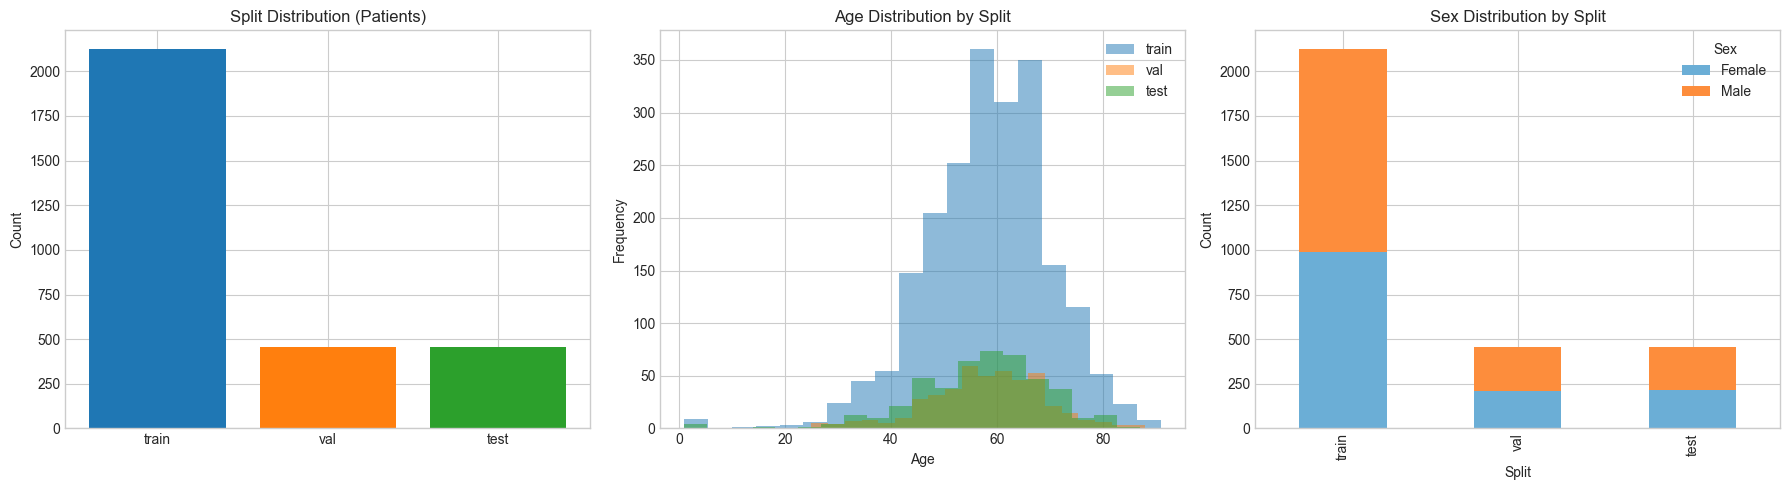

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
split_order = ['train', 'val', 'test']
counts = [int((all_df['split'] == s).sum()) for s in split_order]
axes[0].bar(split_order, counts, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_title('Split Distribution (Patients)')
axes[0].set_ylabel('Count')
for s, c in zip(split_order, ['#1f77b4', '#ff7f0e', '#2ca02c']):
    axes[1].hist(all_df.loc[all_df['split'] == s, 'age'], bins=20, alpha=0.5, label=s, color=c)
axes[1].set_title('Age Distribution by Split')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')
axes[1].legend()
sex_ct = all_df.groupby(['split', 'sex']).size().unstack(fill_value=0).reindex(split_order)
sex_ct.plot(kind='bar', stacked=True, ax=axes[2], color=['#6baed6', '#fd8d3c'])
axes[2].set_title('Sex Distribution by Split')
axes[2].set_xlabel('Split')
axes[2].set_ylabel('Count')
axes[2].legend(title='Sex')
plt.tight_layout()
save_current_fig('cell07_fig1')
plt.show()


Saved figure: E:\EYE_HEART_CONNECTION\photos\02_cell08_fig2.png


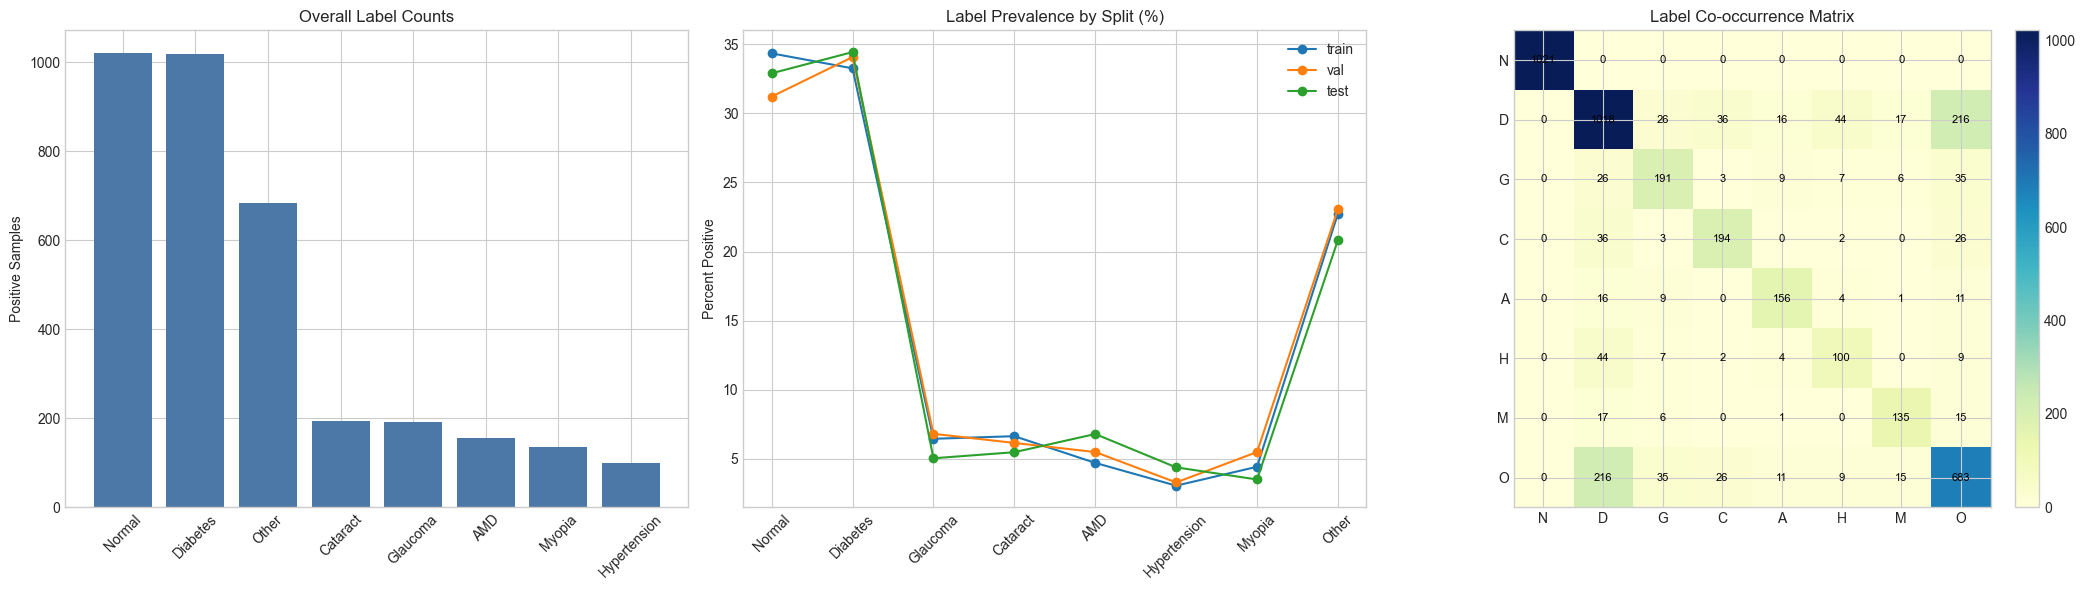

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
label_counts = all_df[LABELS].sum().sort_values(ascending=False)
axes[0].bar([LABEL_NAMES[l] for l in label_counts.index], label_counts.values, color='#4c78a8')
axes[0].set_title('Overall Label Counts')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Positive Samples')
prev = all_df.groupby('split')[LABELS].mean().reindex(['train', 'val', 'test']) * 100
for split in prev.index:
    axes[1].plot([LABEL_NAMES[l] for l in LABELS], prev.loc[split].values, marker='o', label=split)
axes[1].set_title('Label Prevalence by Split (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Percent Positive')
axes[1].legend()
co = all_df[LABELS].T.dot(all_df[LABELS])
im = axes[2].imshow(co.values, cmap='YlGnBu')
axes[2].set_title('Label Co-occurrence Matrix')
axes[2].set_xticks(range(len(LABELS)))
axes[2].set_yticks(range(len(LABELS)))
axes[2].set_xticklabels(LABELS)
axes[2].set_yticklabels(LABELS)
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        axes[2].text(j, i, int(co.values[i, j]), ha='center', va='center', color='black', fontsize=8)
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
plt.tight_layout()
save_current_fig('cell08_fig2')
plt.show()


## 4) Sample Retinal Pairs
A few random patient samples with left/right eye images and their positive labels.


Saved figure: E:\EYE_HEART_CONNECTION\photos\03_cell10_fig3.png


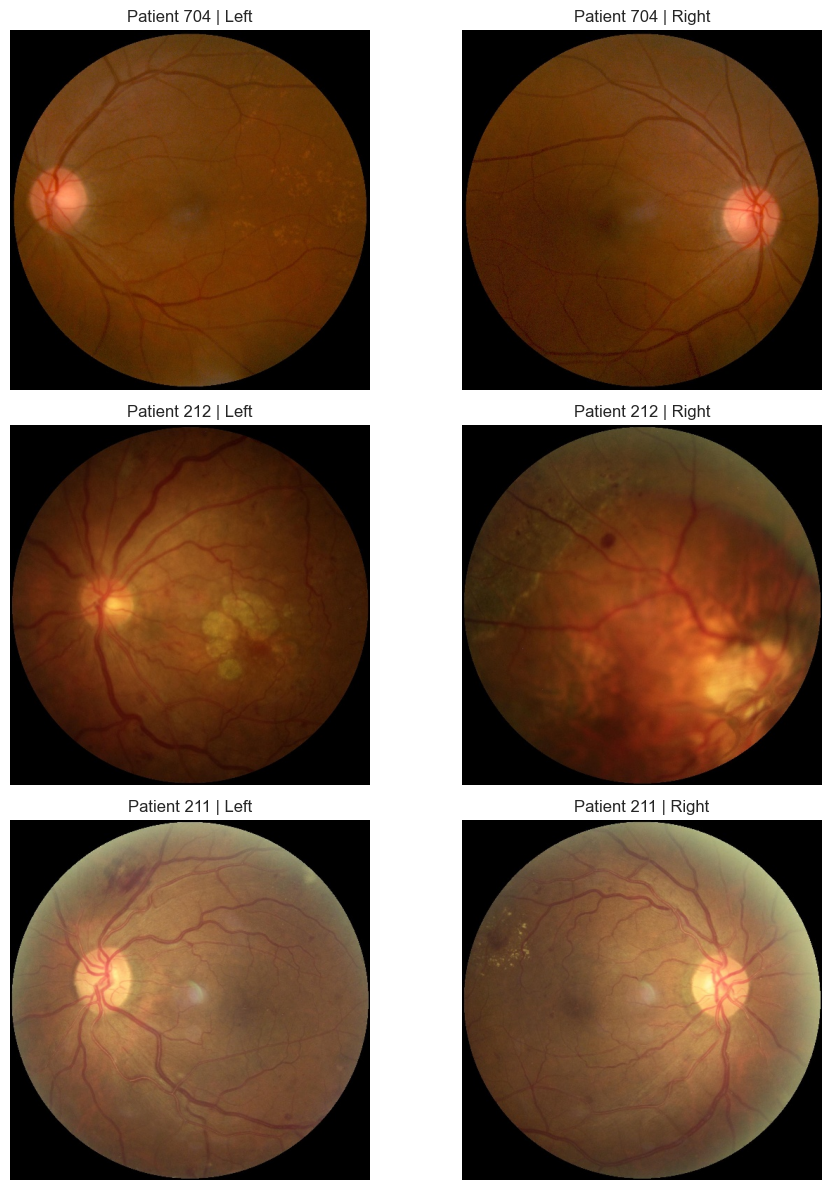

In [6]:
import cv2
sample_n = 3
sample_df = all_df.sample(sample_n, random_state=42).reset_index(drop=True)
fig, axes = plt.subplots(sample_n, 2, figsize=(10, 4 * sample_n))
if sample_n == 1:
    axes = np.array([axes])
for i, row in sample_df.iterrows():
    left_path = IMAGES_DIR / str(row['left_image'])
    right_path = IMAGES_DIR / str(row['right_image'])
    active_labels = [LABEL_NAMES[l] for l in LABELS if int(row[l]) == 1]
    label_text = ', '.join(active_labels) if active_labels else 'None'
    for j, img_path in enumerate([left_path, right_path]):
        ax = axes[i, j]
        if img_path.exists():
            img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.set_title(f"Patient {row['patient_id']} | {'Left' if j == 0 else 'Right'}")
        else:
            ax.text(0.5, 0.5, f'Missing image:\n{img_path.name}', ha='center', va='center')
        ax.axis('off')
    axes[i, 0].set_xlabel(f"Age: {row['age']} | Labels: {label_text}")
plt.tight_layout()
save_current_fig('cell10_fig3')
plt.show()


## 5) Multimodal Architecture (Concept)
The model combines two image encodings and one metadata encoding before final multi-label prediction.


Saved figure: E:\EYE_HEART_CONNECTION\photos\04_cell12_fig4.png


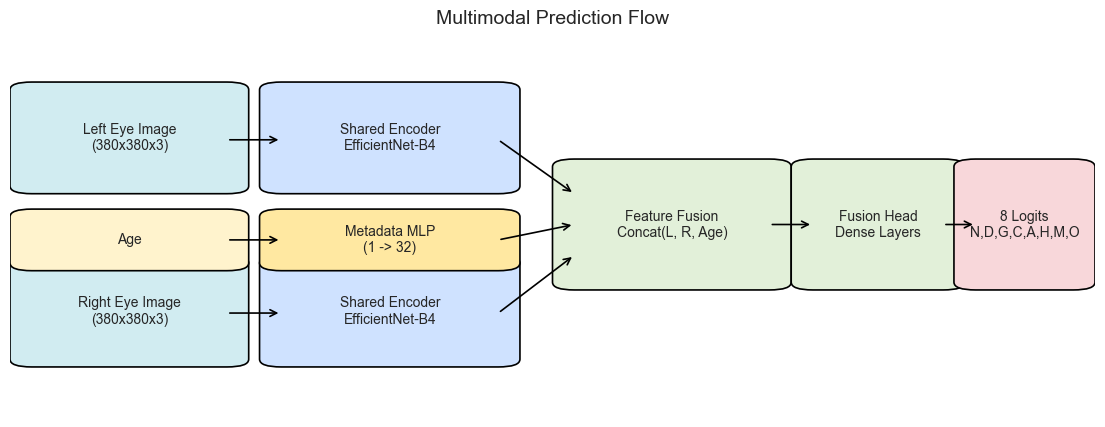

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')
def add_box(x, y, w, h, text, color='#d9ecff'):
    box = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.02', fc=color, ec='black', lw=1.2)
    ax.add_patch(box)
    ax.text(x + w / 2, y + h / 2, text, ha='center', va='center', fontsize=10)
add_box(0.02, 0.60, 0.18, 0.25, 'Left Eye Image\n(380x380x3)', '#d1ecf1')
add_box(0.02, 0.15, 0.18, 0.25, 'Right Eye Image\n(380x380x3)', '#d1ecf1')
add_box(0.25, 0.60, 0.20, 0.25, 'Shared Encoder\nEfficientNet-B4', '#cfe2ff')
add_box(0.25, 0.15, 0.20, 0.25, 'Shared Encoder\nEfficientNet-B4', '#cfe2ff')
add_box(0.02, 0.40, 0.18, 0.12, 'Age', '#fff3cd')
add_box(0.25, 0.40, 0.20, 0.12, 'Metadata MLP\n(1 -> 32)', '#ffe8a1')
add_box(0.52, 0.35, 0.18, 0.30, 'Feature Fusion\nConcat(L, R, Age)', '#e2f0d9')
add_box(0.74, 0.35, 0.12, 0.30, 'Fusion Head\nDense Layers', '#e2f0d9')
add_box(0.89, 0.35, 0.09, 0.30, '8 Logits\nN,D,G,C,A,H,M,O', '#f8d7da')
arrows = [
    ((0.20, 0.72), (0.25, 0.72)),
    ((0.20, 0.27), (0.25, 0.27)),
    ((0.20, 0.46), (0.25, 0.46)),
    ((0.45, 0.72), (0.52, 0.58)),
    ((0.45, 0.27), (0.52, 0.42)),
    ((0.45, 0.46), (0.52, 0.50)),
    ((0.70, 0.50), (0.74, 0.50)),
    ((0.86, 0.50), (0.89, 0.50)),
]
for start, end in arrows:
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle='->', mutation_scale=12, lw=1.2, color='black'))
ax.set_title('Multimodal Prediction Flow', fontsize=14)
save_current_fig('cell12_fig4')
plt.show()


## 6) Training Dynamics
We visualize how loss and key metrics evolved across epochs.


Saved figure: E:\EYE_HEART_CONNECTION\photos\05_cell14_fig5.png


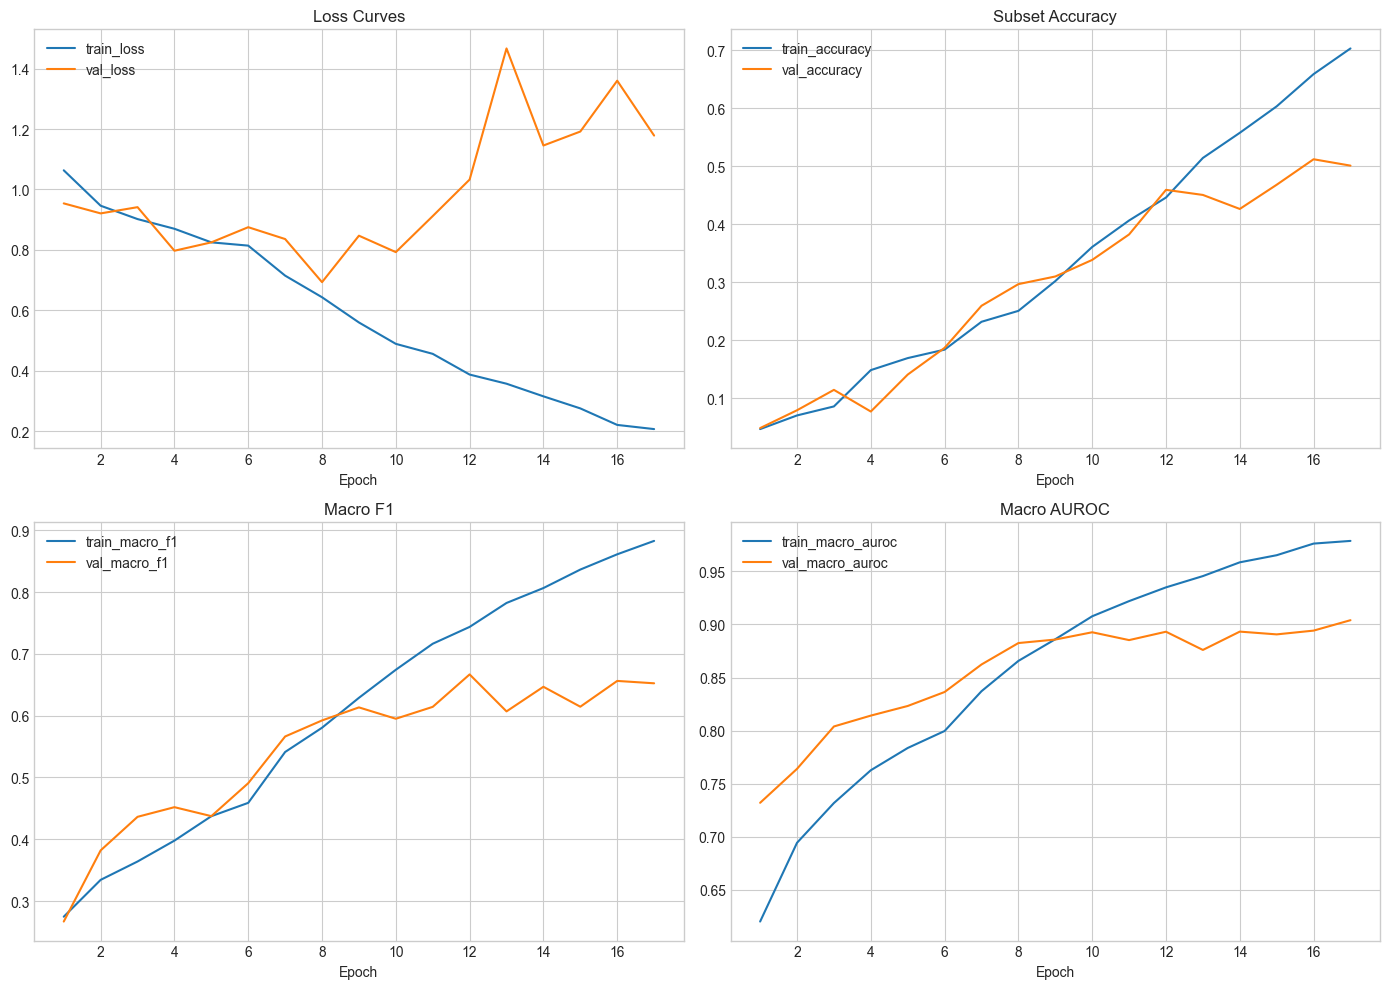

Best epoch by val_f1:


,value
epoch,12.000000
train_loss,0.387004
val_loss,1.032735
lr,0.000197
train_accuracy,0.446067
train_precision,0.662330
train_recall,0.857098
train_f1,0.743760
train_macro_auroc,0.934909
train_macro_pr_auc,0.819045


In [8]:
if RUN_DIR is None:
    raise FileNotFoundError('No run directory with metrics.csv found under experiments/.')
metrics_df = pd.read_csv(RUN_DIR / 'metrics.csv')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].plot(metrics_df['epoch'], metrics_df['train_loss'], label='train_loss')
axes[0, 0].plot(metrics_df['epoch'], metrics_df['val_loss'], label='val_loss')
axes[0, 0].set_title('Loss Curves')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()
axes[0, 1].plot(metrics_df['epoch'], metrics_df['train_accuracy'], label='train_accuracy')
axes[0, 1].plot(metrics_df['epoch'], metrics_df['val_accuracy'], label='val_accuracy')
axes[0, 1].set_title('Subset Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()
axes[1, 0].plot(metrics_df['epoch'], metrics_df['train_f1'], label='train_macro_f1')
axes[1, 0].plot(metrics_df['epoch'], metrics_df['val_f1'], label='val_macro_f1')
axes[1, 0].set_title('Macro F1')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()
axes[1, 1].plot(metrics_df['epoch'], metrics_df['train_macro_auroc'], label='train_macro_auroc')
axes[1, 1].plot(metrics_df['epoch'], metrics_df['val_macro_auroc'], label='val_macro_auroc')
axes[1, 1].set_title('Macro AUROC')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].legend()
plt.tight_layout()
save_current_fig('cell14_fig5')
plt.show()
best_idx = metrics_df['val_f1'].idxmax()
best_epoch = metrics_df.loc[best_idx]
print('Best epoch by val_f1:')
display(best_epoch.to_frame('value'))


,accuracy,precision,recall,f1,macro_auroc,macro_pr_auc,label_accuracy
val_post_train,0.459341,0.661753,0.679566,0.666829,0.893219,0.684677,0.892033
test_post_train,0.447368,0.590501,0.646158,0.610482,0.875968,0.652486,0.881031


Saved figure: E:\EYE_HEART_CONNECTION\photos\06_cell15_fig6.png


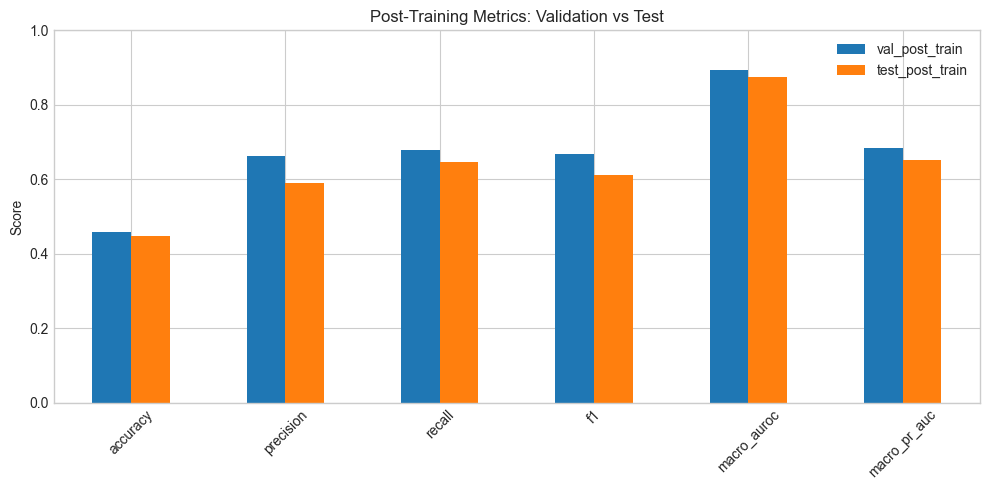

In [9]:
post_report_path = RUN_DIR / 'reports' / 'post_train_metrics.json'
with post_report_path.open('r', encoding='utf-8') as f:
    post_report = json.load(f)
val_post = post_report.get('post_train_val_metrics', {})
test_post = post_report.get('post_train_test_metrics', {})
compare_df = pd.DataFrame([val_post, test_post], index=['val_post_train', 'test_post_train'])
display(compare_df)
ax = compare_df[['accuracy', 'precision', 'recall', 'f1', 'macro_auroc', 'macro_pr_auc']].T.plot(
    kind='bar', figsize=(10, 5), color=['#1f77b4', '#ff7f0e']
)
ax.set_title('Post-Training Metrics: Validation vs Test')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
save_current_fig('cell15_fig6')
plt.show()


## 7) Evaluation Results (Test Split)
Global-threshold and tuned-threshold comparisons.


,metric_set,accuracy,precision,recall,f1,macro_auroc,macro_pr_auc,label_accuracy
0,global,0.447368,0.590501,0.646158,0.610482,0.875968,0.652486,0.881031
1,tuned,0.353070,0.622537,0.695763,0.640950,0.875968,0.652486,0.873355


Saved figure: E:\EYE_HEART_CONNECTION\photos\07_cell17_fig7.png


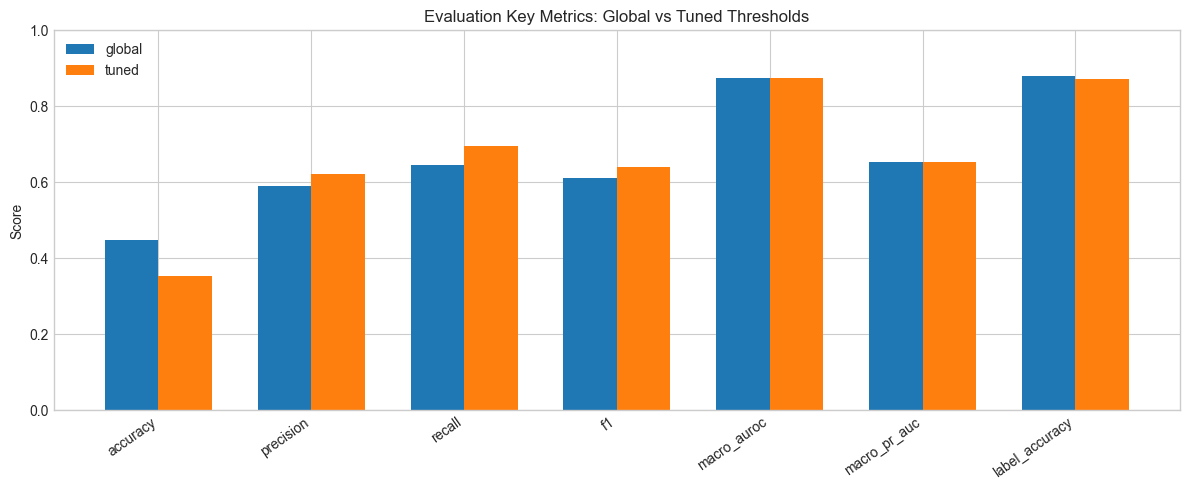

In [10]:
eval_key_df = pd.read_csv(PROCESSED_DIR / 'eval_key_metrics.csv')
display(eval_key_df)
plot_cols = ['accuracy', 'precision', 'recall', 'f1', 'macro_auroc', 'macro_pr_auc', 'label_accuracy']
long_df = eval_key_df.melt(id_vars='metric_set', value_vars=plot_cols, var_name='metric', value_name='score')
fig, ax = plt.subplots(figsize=(12, 5))
for i, metric_set in enumerate(long_df['metric_set'].unique()):
    sub = long_df[long_df['metric_set'] == metric_set]
    x = np.arange(len(plot_cols)) + (i - 0.5) * 0.35
    ax.bar(x, sub['score'].values, width=0.35, label=metric_set)
ax.set_xticks(np.arange(len(plot_cols)))
ax.set_xticklabels(plot_cols, rotation=35, ha='right')
ax.set_ylim(0, 1)
ax.set_title('Evaluation Key Metrics: Global vs Tuned Thresholds')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
save_current_fig('cell17_fig7')
plt.show()


,label,label_name,accuracy,precision,recall,f1,auroc,pr_auc
0,N,Normal,0.752193,0.595855,0.766667,0.670554,0.835490,0.664254
1,D,Diabetes,0.750000,0.604878,0.789809,0.685083,0.846154,0.792114
2,G,Glaucoma,0.932018,0.366667,0.478261,0.415094,0.929712,0.511797
3,C,Cataract,0.969298,0.677419,0.840000,0.750000,0.945244,0.817060
4,A,AMD,0.949561,0.617647,0.677419,0.646154,0.931385,0.716471
5,H,Hypertension,0.953947,0.461538,0.300000,0.363636,0.780619,0.291244
6,M,Myopia,0.995614,1.000000,0.875000,0.933333,0.997017,0.951901
7,O,Other,0.745614,0.400000,0.442105,0.420000,0.742120,0.475044


Saved figure: E:\EYE_HEART_CONNECTION\photos\08_cell18_fig8.png


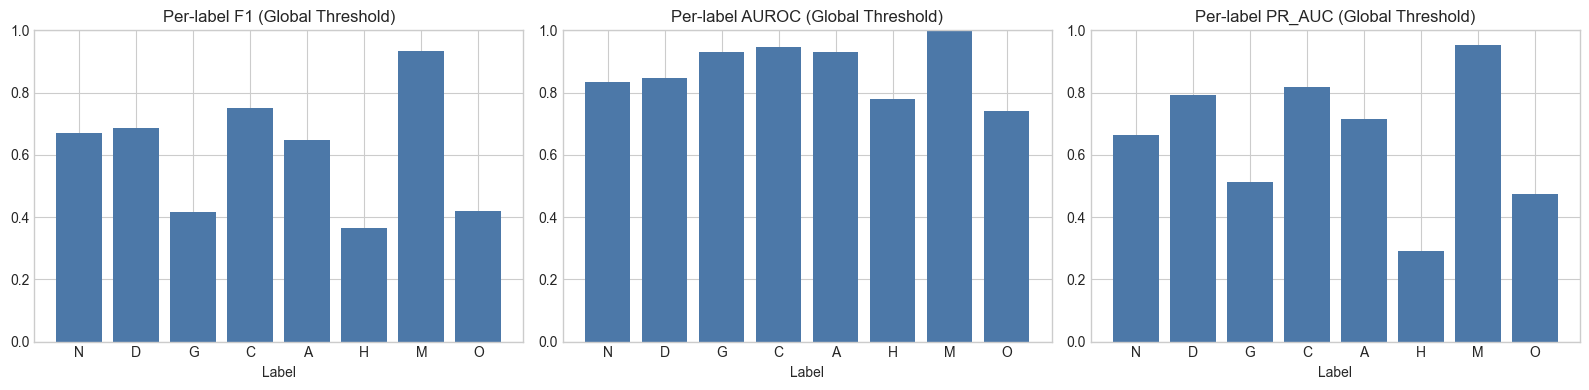

In [11]:
with (PROCESSED_DIR / 'eval_report.json').open('r', encoding='utf-8') as f:
    eval_report = json.load(f)
global_per = pd.DataFrame(eval_report['global_metrics']['per_label']).T
global_per.index.name = 'label'
global_per = global_per.reset_index()
global_per['label_name'] = global_per['label'].map(LABEL_NAMES)
display(global_per[['label', 'label_name', 'accuracy', 'precision', 'recall', 'f1', 'auroc', 'pr_auc']])
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ['f1', 'auroc', 'pr_auc']):
    ax.bar(global_per['label'], global_per[metric], color='#4c78a8')
    ax.set_title(f'Per-label {metric.upper()} (Global Threshold)')
    ax.set_ylim(0, 1)
    ax.set_xlabel('Label')
plt.tight_layout()
save_current_fig('cell18_fig8')
plt.show()


Saved figure: E:\EYE_HEART_CONNECTION\photos\09_cell19_fig9.png


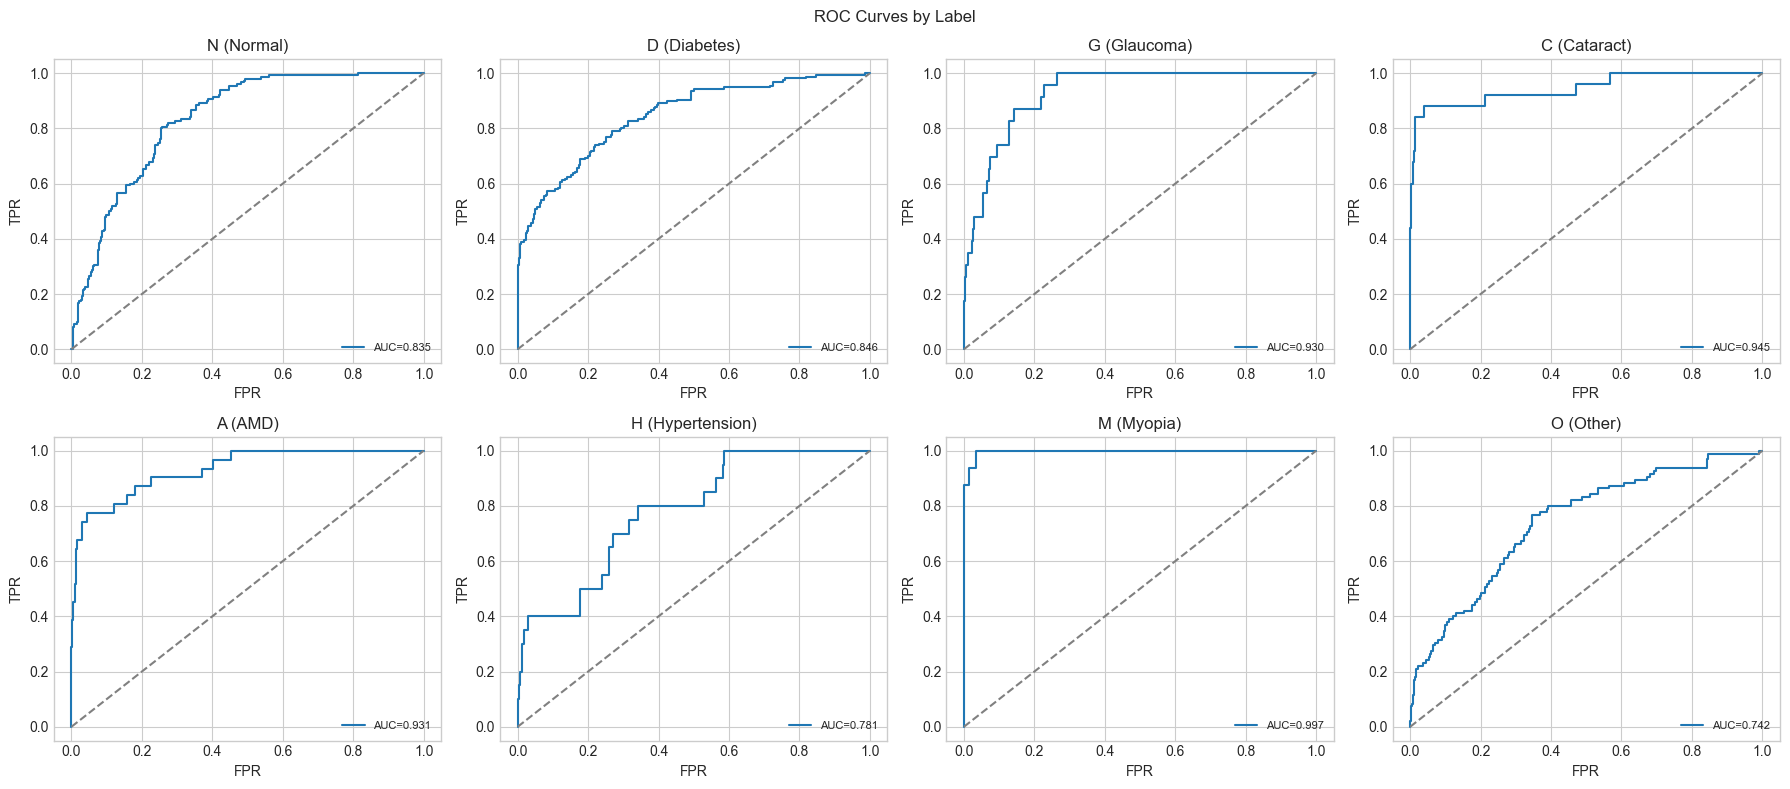

Saved figure: E:\EYE_HEART_CONNECTION\photos\10_cell19_fig10.png


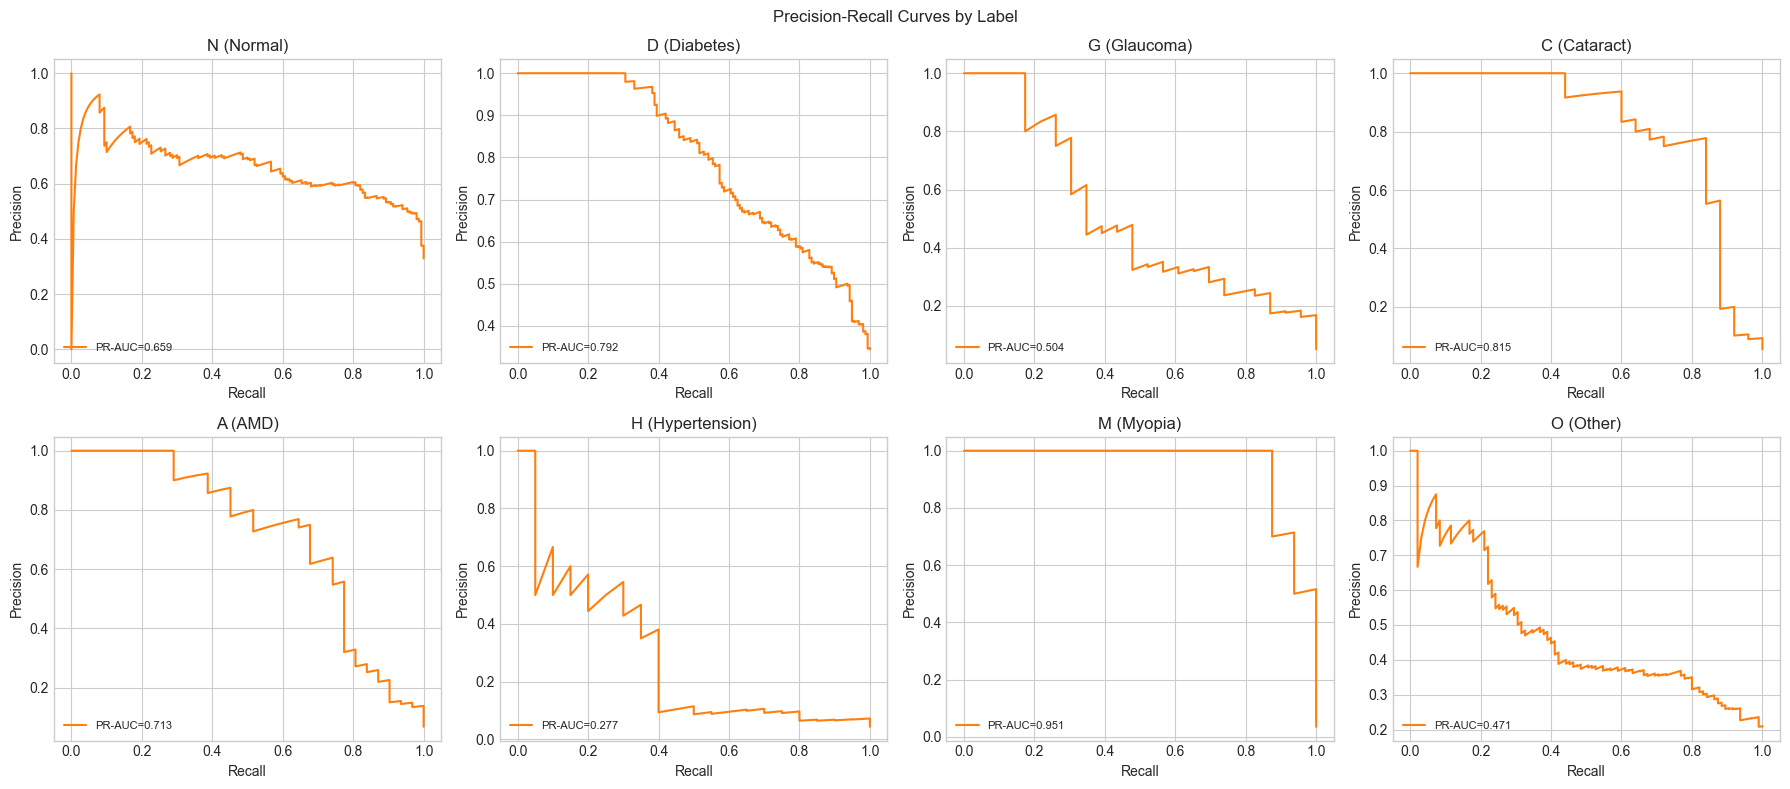

In [12]:
pred_df = pd.read_csv(PROCESSED_DIR / 'eval_predictions.csv')
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for i, label in enumerate(LABELS):
    y_true = pred_df[f'true_{label}'].values
    y_prob = pred_df[f'prob_{label}'].values
    ax = axes[i]
    try:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'AUC={roc_auc:.3f}', color='#1f77b4')
        ax.plot([0, 1], [0, 1], '--', color='gray')
    except Exception:
        ax.text(0.5, 0.5, 'Insufficient class\nvariation', ha='center', va='center')
    ax.set_title(f"{label} ({LABEL_NAMES[label]})")
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(loc='lower right', fontsize=8)
plt.suptitle('ROC Curves by Label')
plt.tight_layout()
save_current_fig('cell19_fig9')
plt.show()
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for i, label in enumerate(LABELS):
    y_true = pred_df[f'true_{label}'].values
    y_prob = pred_df[f'prob_{label}'].values
    ax = axes[i]
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)
    ax.plot(recall, precision, label=f'PR-AUC={pr_auc:.3f}', color='#ff7f0e')
    ax.set_title(f"{label} ({LABEL_NAMES[label]})")
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend(loc='lower left', fontsize=8)
plt.suptitle('Precision-Recall Curves by Label')
plt.tight_layout()
save_current_fig('cell19_fig10')
plt.show()


Saved figure: E:\EYE_HEART_CONNECTION\photos\11_cell20_fig11.png


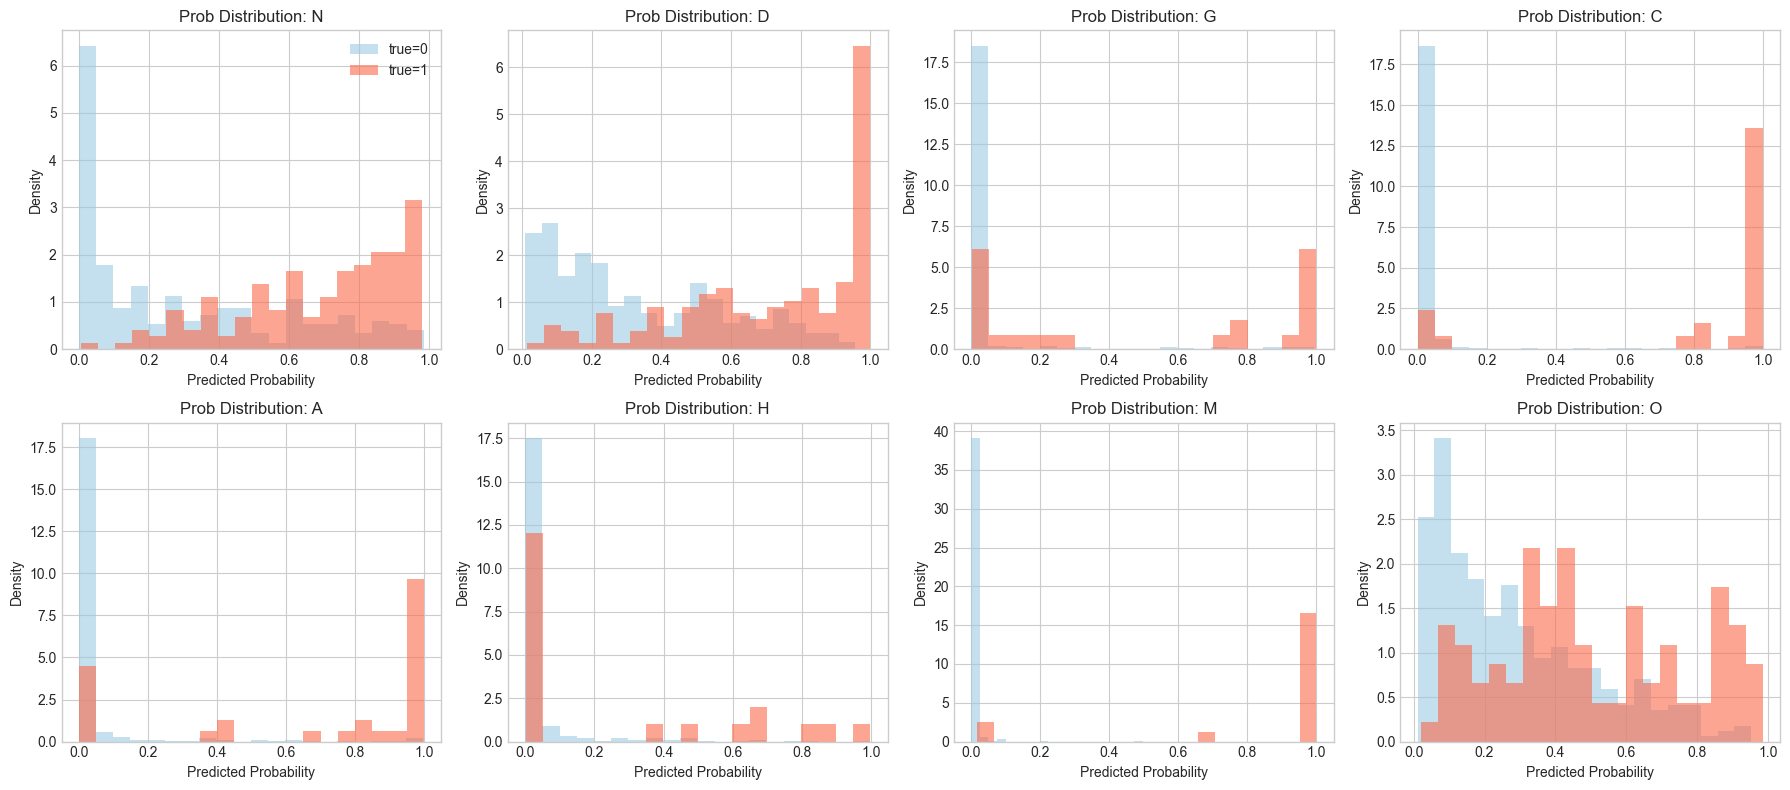

,label,true_prevalence,predicted_positive_rate
0,N,0.328947,0.469298
1,D,0.344298,0.449561
2,G,0.050439,0.054825
3,C,0.054825,0.059211
4,A,0.067982,0.063596
5,H,0.043860,0.026316
6,M,0.035088,0.030702
7,O,0.208333,0.458333


Saved figure: E:\EYE_HEART_CONNECTION\photos\12_cell20_fig12.png


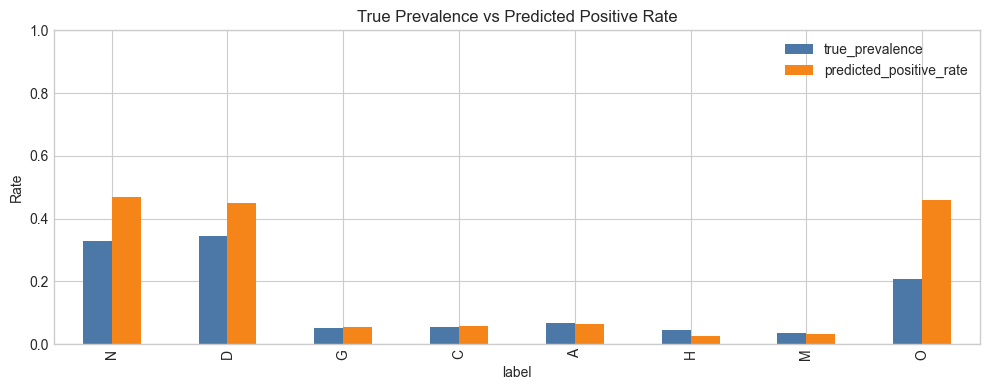

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for i, label in enumerate(LABELS):
    ax = axes[i]
    y_true = pred_df[f'true_{label}'].values
    y_prob = pred_df[f'prob_{label}'].values
    ax.hist(y_prob[y_true == 0], bins=20, alpha=0.6, label='true=0', color='#9ecae1', density=True)
    ax.hist(y_prob[y_true == 1], bins=20, alpha=0.6, label='true=1', color='#fb6a4a', density=True)
    ax.set_title(f'Prob Distribution: {label}')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Density')
    if i == 0:
        ax.legend()
plt.tight_layout()
save_current_fig('cell20_fig11')
plt.show()
prevalence_rows = []
for label in LABELS:
    true_prev = pred_df[f'true_{label}'].mean()
    pred_prev = pred_df[f'pred_{label}'].mean()
    prevalence_rows.append({'label': label, 'true_prevalence': true_prev, 'predicted_positive_rate': pred_prev})
prev_df = pd.DataFrame(prevalence_rows)
display(prev_df)
ax = prev_df.set_index('label').plot(kind='bar', figsize=(10, 4), color=['#4c78a8', '#f58518'])
ax.set_ylim(0, 1)
ax.set_title('True Prevalence vs Predicted Positive Rate')
ax.set_ylabel('Rate')
plt.tight_layout()
save_current_fig('cell20_fig12')
plt.show()


## 8) Inference Demo with Trained Model
We run inference on sampled test patients using the saved checkpoint.


In [14]:
from utils.config import (
    load_cv_proxy_config,
    load_data_config,
    load_inference_config,
    load_model_config,
)
from inference.predictor import Predictor
ckpt_path = BEST_CKPT if BEST_CKPT.exists() else (RUN_DIR / 'checkpoints' / 'best.pt')
predictor = Predictor(
    checkpoint_path=ckpt_path,
    model_config=load_model_config(PROJECT_ROOT / 'configs' / 'model.yaml'),
    data_config=load_data_config(PROJECT_ROOT / 'configs' / 'data.yaml', project_root=PROJECT_ROOT),
    inference_config=load_inference_config(PROJECT_ROOT / 'configs' / 'inference.yaml', project_root=PROJECT_ROOT),
    cv_proxy_config=load_cv_proxy_config(PROJECT_ROOT / 'configs' / 'cv_proxy.yaml'),
)
demo_rows = test_df.sample(3, random_state=7).reset_index(drop=True)
results = []
for _, row in demo_rows.iterrows():
    left_path = IMAGES_DIR / str(row['left_image'])
    right_path = IMAGES_DIR / str(row['right_image'])
    out = predictor.predict_single(left_image=left_path, right_image=right_path, age=float(row['age']))
    top3 = sorted(out.probabilities.items(), key=lambda x: x[1], reverse=True)[:3]
    results.append({
        'patient_id': row['patient_id'],
        'age': row['age'],
        'risk_band': out.cv_summary['risk_band'],
        'overall_cv_proxy': out.cv_summary['overall_cv_proxy'],
        'top3_labels': ', '.join([f"{k}:{v:.3f}" for k, v in top3]),
    })
result_df = pd.DataFrame(results)
display(result_df)


,patient_id,age,risk_band,overall_cv_proxy,top3_labels
0,3139,54.0,high,0.685390,"G:0.824, H:0.809, D:0.669"
1,17,57.0,medium,0.432755,"A:0.624, O:0.590, D:0.509"
2,2772,41.0,low,0.031016,"N:0.962, O:0.120, D:0.075"


Saved figure: E:\EYE_HEART_CONNECTION\photos\13_cell23_fig13.png


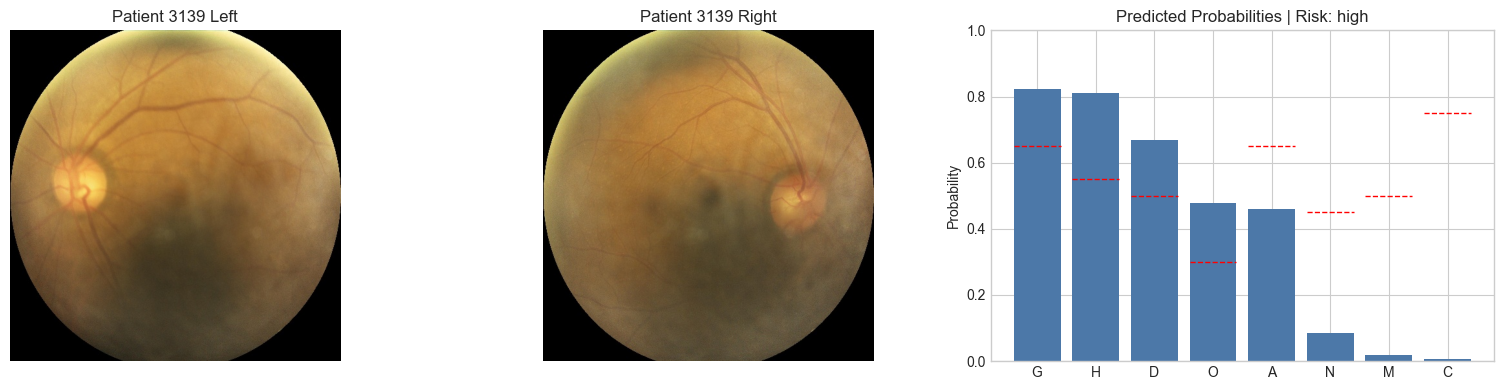

CV Summary: {'hypertension_proxy': 0.7463744401931764, 'diabetes_proxy': 0.6972737789154053, 'atherosclerotic_proxy': 0.5711788058280945, 'overall_cv_proxy': 0.685390300154686, 'risk_band': 'high'}


In [15]:
row = demo_rows.iloc[0]
left_path = IMAGES_DIR / str(row['left_image'])
right_path = IMAGES_DIR / str(row['right_image'])
out = predictor.predict_single(left_image=left_path, right_image=right_path, age=float(row['age']))
probs = pd.Series(out.probabilities).sort_values(ascending=False)
thresholds = pd.Series(predictor.thresholds)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
img_l = cv2.cvtColor(cv2.imread(str(left_path)), cv2.COLOR_BGR2RGB)
axes[0].imshow(img_l)
axes[0].set_title(f"Patient {row['patient_id']} Left")
axes[0].axis('off')
img_r = cv2.cvtColor(cv2.imread(str(right_path)), cv2.COLOR_BGR2RGB)
axes[1].imshow(img_r)
axes[1].set_title(f"Patient {row['patient_id']} Right")
axes[1].axis('off')
axes[2].bar(probs.index, probs.values, color='#4c78a8')
for i, lbl in enumerate(probs.index):
    axes[2].hlines(thresholds[lbl], i - 0.4, i + 0.4, colors='red', linestyles='--', linewidth=1)
axes[2].set_ylim(0, 1)
axes[2].set_title(f"Predicted Probabilities | Risk: {out.cv_summary['risk_band']}")
axes[2].set_ylabel('Probability')
plt.tight_layout()
save_current_fig('cell23_fig13')
plt.show()
print('CV Summary:', out.cv_summary)


## 9) Optional Full Training Cell (Disabled by Default)
For hackathon demo, heavy training is kept disabled. Set RUN_FULL_TRAINING = True only if you intentionally want to train again.


In [16]:
RUN_FULL_TRAINING = False
if RUN_FULL_TRAINING:
    import subprocess
    train_cmd = [
        'python', '-m', 'training.train',
        '--config', 'configs/train.yaml',
        '--data-config', 'configs/data.yaml',
        '--model-config', 'configs/model.yaml',
    ]
    eval_cmd = [
        'python', '-m', 'evaluation.run',
        '--config', 'configs/eval.yaml',
        '--data-config', 'configs/data.yaml',
        '--model-config', 'configs/model.yaml',
        '--ckpt', 'experiments/latest/best.pt',
    ]
    subprocess.run(train_cmd, cwd=str(PROJECT_ROOT), check=True)
    subprocess.run(eval_cmd, cwd=str(PROJECT_ROOT), check=True)
else:
    print('Training disabled for showcase notebook. Toggle RUN_FULL_TRAINING=True to run.')


Training disabled for showcase notebook. Toggle RUN_FULL_TRAINING=True to run.


## 10) Deployment & Presentation Checklist
This checklist confirms the core artifacts required for API deployment and demo continuity.


In [17]:
deploy_checks = {
    'best_checkpoint': PROJECT_ROOT / 'experiments/latest/best.pt',
    'model_config': PROJECT_ROOT / 'configs/model.yaml',
    'data_config': PROJECT_ROOT / 'configs/data.yaml',
    'inference_config': PROJECT_ROOT / 'configs/inference.yaml',
    'cv_proxy_config': PROJECT_ROOT / 'configs/cv_proxy.yaml',
    'metadata_stats': PROJECT_ROOT / 'data/processed/metadata_stats.json',
    'thresholds': PROJECT_ROOT / 'data/processed/thresholds.json',
    'eval_report': PROJECT_ROOT / 'data/processed/eval_report.json',
    'eval_predictions': PROJECT_ROOT / 'data/processed/eval_predictions.csv',
}
check_df = pd.DataFrame([
    {'item': k, 'path': str(v), 'exists': v.exists()}
    for k, v in deploy_checks.items()
])
display(check_df)
missing = check_df.loc[~check_df['exists'], 'item'].tolist()
if missing:
    print('Missing items:', missing)
else:
    print('All essential deployment/demo artifacts are present.')


,item,path,exists
0,best_checkpoint,E:\EYE_HEART_CONNECTION\experiments\latest\bes...,True
1,model_config,E:\EYE_HEART_CONNECTION\configs\model.yaml,True
2,data_config,E:\EYE_HEART_CONNECTION\configs\data.yaml,True
3,inference_config,E:\EYE_HEART_CONNECTION\configs\inference.yaml,True
4,cv_proxy_config,E:\EYE_HEART_CONNECTION\configs\cv_proxy.yaml,True
5,metadata_stats,E:\EYE_HEART_CONNECTION\data\processed\metadat...,True
6,thresholds,E:\EYE_HEART_CONNECTION\data\processed\thresho...,True
7,eval_report,E:\EYE_HEART_CONNECTION\data\processed\eval_re...,True
8,eval_predictions,E:\EYE_HEART_CONNECTION\data\processed\eval_pr...,True


All essential deployment/demo artifacts are present.


## End of Showcase
You now have a complete visual narrative:
- data quality and distribution
- model architecture and multimodal fusion
- training progression
- test/evaluation performance
- inference behavior
- deployment readiness
This notebook is presentation-ready for hackathon demo flow.
